In [2]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import SimpleITK as sitk
import recon_plot_helpers

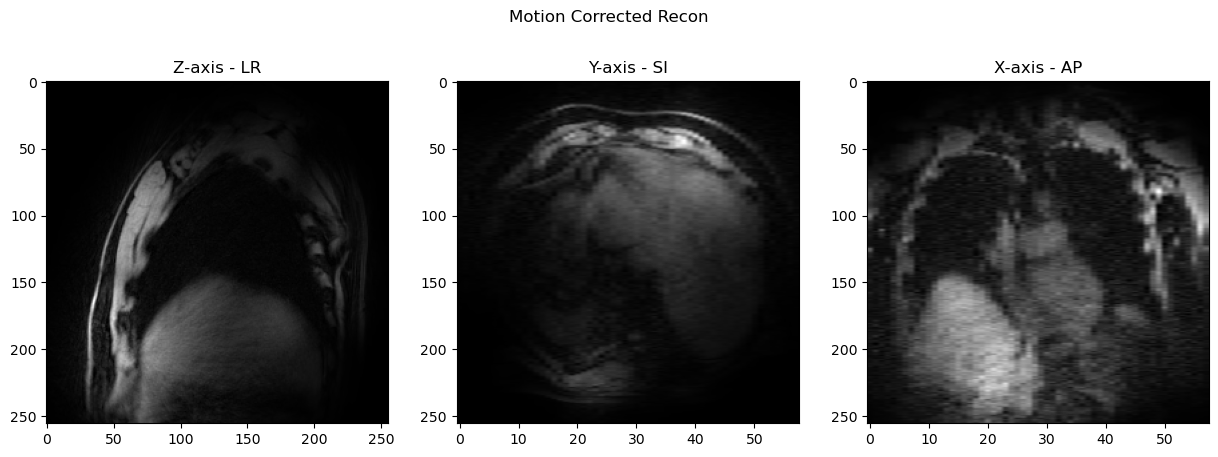

In [29]:
## Base directory where everything is located
base_dir = f"/home/lilianae/projects/naf_clean/admm_results/subject2_mid0082_nifti_files"

## Lambda = motion corrected image
lam_path = os.path.join(base_dir,"lam.nii")
ref_img = sitk.GetArrayFromImage(sitk.ReadImage(lam_path))

# Extract center indices for plotting
z_idx = 44
y_idx = 210
# Plot at the center of the Liver ROI
fig, ax = recon_plot_helpers.plot_recons_all_axes(
    ref_img, 
    z_idx=z_idx, 
    y_idx=y_idx, 
    column_titles=True,
    title="Motion Corrected Recon"
)

### 1. aSNR (test)

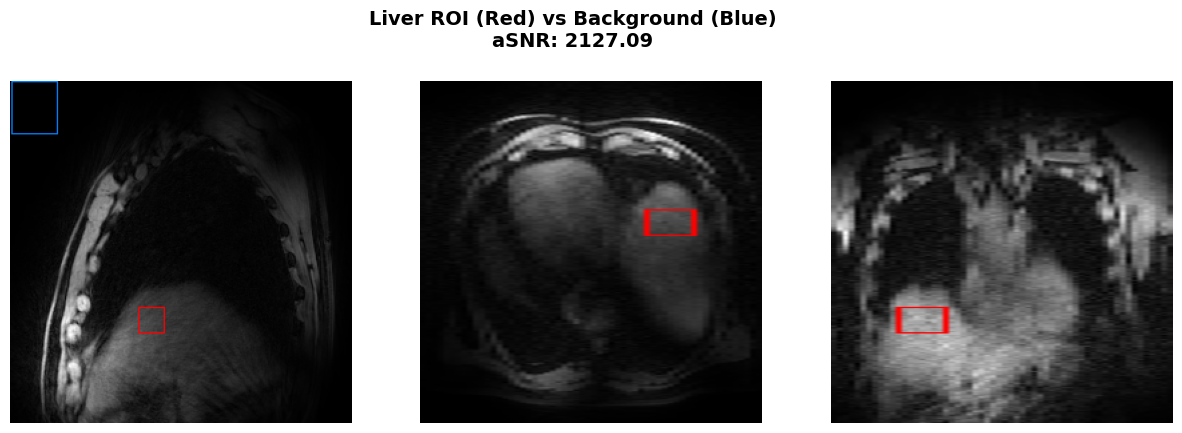

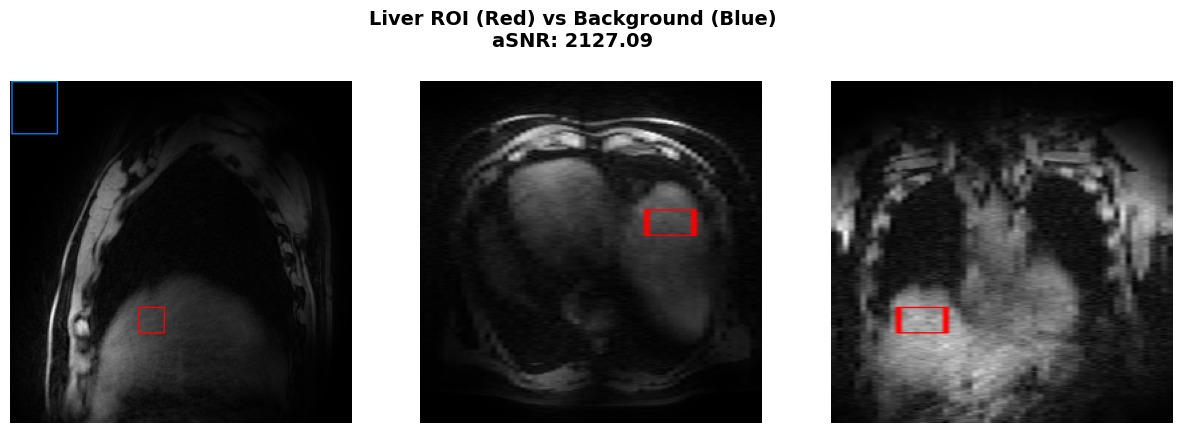

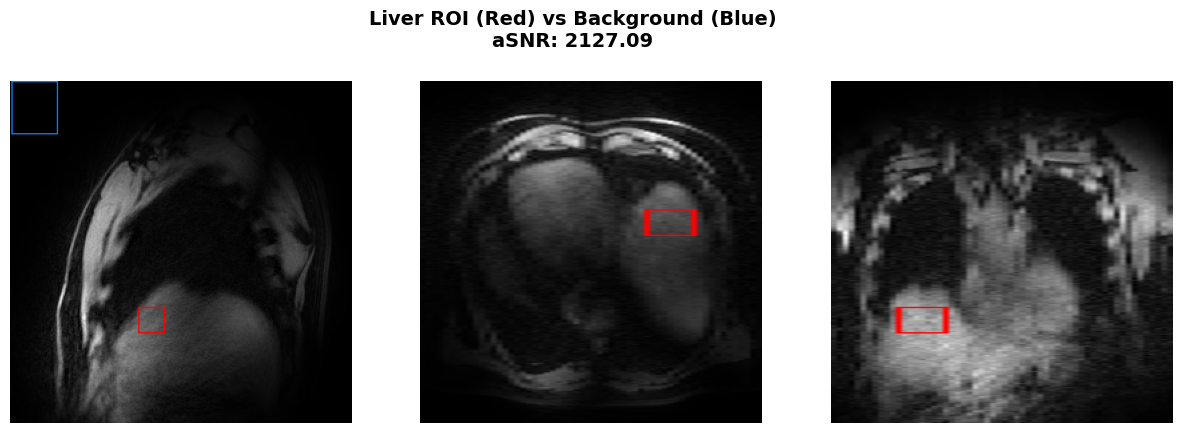

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def plot_colored_rois(img, z_idx, y_idx, x_idx, roi_slices, bg_slices, title=""):
    """
    Plots 3-axis views with Liver ROI in Red and Background ROI in Blue.
    roi_slices: (z_s, y_s, x_s) for liver
    bg_slices: (z_s, y_s, x_s) for background
    """
    def get_rgb_slice(slice_2d):
        # Normalize and convert grayscale to RGB
        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max - s_min == 0:
            norm = np.zeros_like(slice_2d)
        else:
            norm = (slice_2d - s_min) / (s_max - s_min)
        return np.stack([norm]*3, axis=-1)

    # 1. Extract Slices
    Nz, Ny, Nx = img.shape
    axial = get_rgb_slice(img[z_idx, :, :])      # XY
    coronal = get_rgb_slice(img[:, y_idx, :])    # XZ
    sagittal = get_rgb_slice(img[:, :, x_idx])   # YZ

    # 2. Define Colors
    RED = [1, 0, 0]
    BLUE = [0, 0.5, 1]

    # 3. Helper to draw boundaries on RGB slice
    def draw_box(slice_rgb, dim1_s, dim2_s, color, view='axial'):
        # top/bottom lines
        slice_rgb[dim1_s.start:dim1_s.stop, dim2_s.start, :] = color
        slice_rgb[dim1_s.start:dim1_s.stop, dim2_s.stop-1, :] = color
        # left/right lines
        slice_rgb[dim1_s.start, dim2_s.start:dim2_s.stop, :] = color
        slice_rgb[dim1_s.stop-1, dim2_s.start:dim2_s.stop, :] = color

    # Draw Liver (Red) and BG (Blue)
    # Axial View
    if roi_slices[0].start <= z_idx < roi_slices[0].stop:
        draw_box(axial, roi_slices[1], roi_slices[2], RED)
    if bg_slices[0].start <= z_idx < bg_slices[0].stop:
        draw_box(axial, bg_slices[1], bg_slices[2], BLUE)

    # Coronal View
    if roi_slices[1].start <= y_idx < roi_slices[1].stop:
        draw_box(coronal, roi_slices[0], roi_slices[2], RED)
    if bg_slices[1].start <= y_idx < bg_slices[1].stop:
        draw_box(coronal, bg_slices[0], bg_slices[2], BLUE)

    # Sagittal View
    if roi_slices[2].start <= x_idx < roi_slices[2].stop:
        draw_box(sagittal, roi_slices[0], roi_slices[1], RED)
    if bg_slices[2].start <= x_idx < bg_slices[2].stop:
        draw_box(sagittal, bg_slices[0], bg_slices[1], BLUE)

    ## aSNR calculation
    mean_liver = np.mean(img[roi_slices])
    std_bg = np.std(img[bg_slices])
    asnr = mean_liver / std_bg

    # 4. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')
    fig.suptitle(f'{title}\naSNR: {asnr:.2f}', fontsize=14, color='black', fontweight='bold')
    # fig.patch.set_facecolor('#222222')

    axes[0].imshow(np.rot90(axial, k=2), origin='lower')
    axes[0].set_title(f"Axial (Z={z_idx})", color='white')
    axes[1].imshow(np.fliplr(np.rot90(coronal, k=3)), origin='lower', aspect=Nz/Ny)
    axes[1].set_title(f"Coronal (Y={y_idx})", color='white')
    axes[2].imshow(np.fliplr(np.rot90(sagittal, k=1)), origin='lower', aspect=Nz/Nx)
    axes[2].set_title(f"Sagittal (X={x_idx})", color='white')

    for ax in axes: ax.axis('off')
    plt.show()

# Run
z_roi, y_roi, x_roi = slice(38, 47), slice(169, 189), slice(140, 160)

## Background ROIs (for each 2D view)
z_bgz, y_bgz, x_bgz = slice(38, 47), slice(0, 40), slice(220, 255)
z_bgy, y_bgy, x_bgy = slice(48, 58), slice(169, 189), slice(220, 255)
z_bgx, y_bgx, x_bgx = slice(48, 58), slice(0, 40), slice(140, 160)

z_bg = (z_bgz, y_bgz, x_bgz)
y_bg = (z_bgy, y_bgy, x_bgy)
x_bg = (z_bgx, y_bgx, x_bgx)

zslices_2d = [39, 42, 46]
yslices_2d = [170, 180, 188]
xslices_2d = [141, 151, 159]

for zi in zslices_2d:
    plot_colored_rois(ref_img,
                    z_idx=zi, 
                    y_idx=180, 
                    x_idx=150,
                    roi_slices=(z_roi, y_roi, x_roi), 
                    bg_slices=z_bg, 
                    title="Liver ROI (Red) vs Background (Blue)")

# for yi in yslices_2d:
#     plot_colored_rois(ref_img,
#                     z_idx=44, 
#                     y_idx=yi, 
#                     x_idx=150,
#                     roi_slices=(z_roi, y_roi, x_roi), 
#                     bg_slices=y_bg, 
#                     title="Liver ROI (Red) vs Background (Blue)")

# for xi in xslices_2d:
#     plot_colored_rois(ref_img,
#                     z_idx=44, 
#                     y_idx=163, 
#                     x_idx=xi,
#                     roi_slices=(z_roi, y_roi, x_roi), 
#                     bg_slices=x_bg, 
#                     title="Liver ROI (Red) vs Background (Blue)")